# Phase 2 — Aerobatic Trajectory Generation (walkthrough)

Phase 1 gave us a validated flatness transform: any smooth flat output
`sigma(t) = [x(t), psi(t)]` maps to attitude, body rate, and rotor/flap inputs, and
feasibility is a cheap open-loop evaluation. Phase 2 builds the flat outputs:

1. **Minimum-snap** piecewise polynomials through maneuver waypoints
   (Richter-Bry / Mellinger-Kumar, the same method as MIT-AERA `mfboTrajectory`).
2. **Feasibility** via `TailsitterFeasibility` — the drop-in replacement for the
   quadrotor model: push the trajectory through the Phase-1 flatness transform and
   read off actuator demand.
3. **Time-optimal scaling** — the fastest version of a maneuver that still respects
   the actuator limits, found by a 1-D search over a time multiplier.

All tunables remain in `config/tailsitter.yaml`.

## 0. Setup

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from tailsitter.config import load_config
from tailsitter.trajgen import (min_snap_trajectory, allocate_times,
                                TailsitterFeasibility, time_optimal_scale, maneuvers)
from tailsitter.trajgen.feasibility import make_sigma
from tailsitter.flatness.transform import FlatTransform
from tailsitter.utils.rotation import quat_to_euler_zxy

cfg = load_config()
feas = TailsitterFeasibility(cfg)
flat = FlatTransform(cfg)
print("maneuvers available:", ", ".join(maneuvers.CATALOG))

maneuvers available: line, loop, knife_edge, climbing_turn, immelmann, split_s, differential_thrust_turn, racing_gates


## 1. Define a maneuver and fit a minimum-snap trajectory

We take a vertical **loop** (the vehicle pitches through 360 deg with the wing axis
held horizontal), allocate segment times from the geometry, and fit a snap-minimising
polynomial that flies *through* the figure at an entry/exit speed.

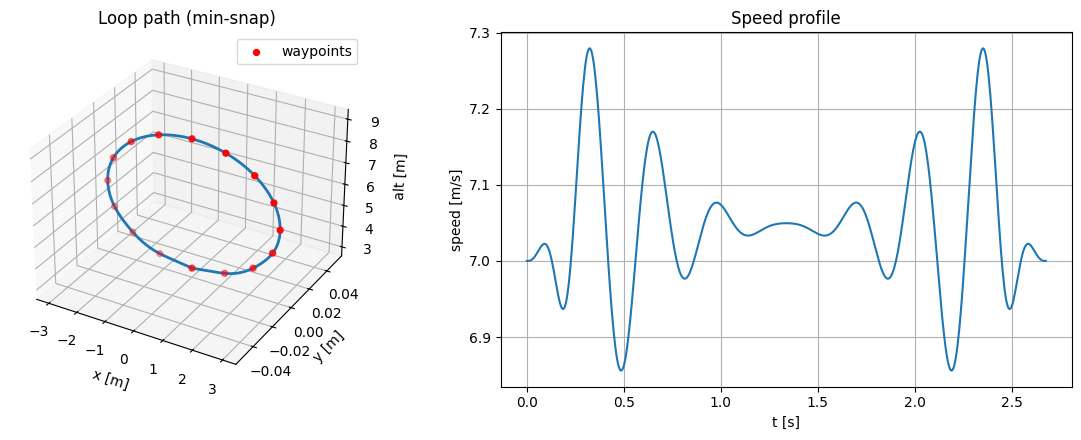

In [2]:
m = maneuvers.loop(radius=3.0, entry_alt=3.0, n=16, speed=7.0)
knots0 = allocate_times(m["waypoints"], m["nominal_speed"])
tp, ty = min_snap_trajectory(m["waypoints"], knots0, yaw=m["yaw"], v0=m["v0"], v1=m["v1"])

ts = np.linspace(knots0[0], knots0[-1], 600)
P = np.array([tp(t) for t in ts]); V = np.array([tp(t, 1) for t in ts])
wp = m["waypoints"]
fig = plt.figure(figsize=(12, 4.5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot(P[:, 0], P[:, 1], -P[:, 2], lw=2)
ax.scatter(wp[:, 0], wp[:, 1], -wp[:, 2], c='r', s=18, label='waypoints')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]'); ax.set_zlabel('alt [m]')
ax.set_title('Loop path (min-snap)'); ax.legend()
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(ts, np.linalg.norm(V, axis=1)); ax2.set_xlabel('t [s]')
ax2.set_ylabel('speed [m/s]'); ax2.set_title('Speed profile'); ax2.grid()
plt.tight_layout(); plt.savefig('plots/p2_loop_path.png', dpi=110); plt.show()

## 2. Feasibility along the trajectory

Run the flatness transform along the trajectory and read off the demanded rotor
speeds and flap angles. At the nominal timing the loop is **infeasible** — the
demand exceeds a limit somewhere. Nothing was integrated; this is the flat map.

duration 2.68s | rotor util 1.04 | flap util 22.66 | feasible: False


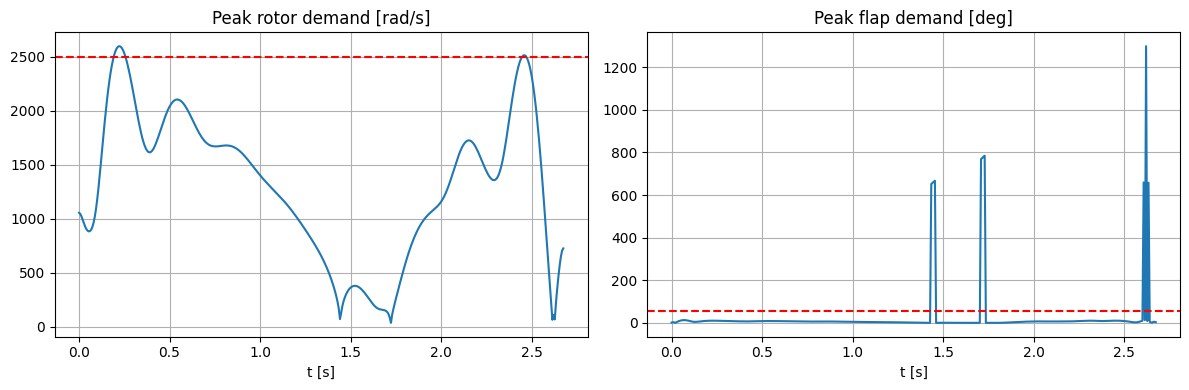

In [3]:
res = feas.evaluate(tp, ty, N=400)
print(f"duration {res['duration']:.2f}s | rotor util {res['w_util']:.2f} | "
      f"flap util {res['flap_util']:.2f} | feasible: {res['feasible']}")
ref = res['ref']; tt = res['ts']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(tt, np.maximum(ref['w1'], ref['w2']))
ax[0].axhline(cfg.vehicle.w_max, ls='--', c='r'); ax[0].set_title('Peak rotor demand [rad/s]')
ax[0].set_xlabel('t [s]'); ax[0].grid()
ax[1].plot(tt, np.degrees(np.maximum(np.abs(ref['d1']), np.abs(ref['d2']))))
ax[1].axhline(np.degrees(cfg.vehicle.flap_max), ls='--', c='r')
ax[1].set_title('Peak flap demand [deg]'); ax[1].set_xlabel('t [s]'); ax[1].grid()
plt.tight_layout(); plt.savefig('plots/p2_demand_nominal.png', dpi=110); plt.show()

## 3. Time-optimal scaling: the feasibility boundary

Scale every segment duration by a single factor `alpha` (small = fast, large = slow)
and find the smallest `alpha` that is feasible everywhere. Plotting actuator
utilisation against `alpha` shows the trajectory pushed right up to a limit — the
fastest the vehicle can fly this shape. This is the core of the paper's feasibility
analysis, done without any closed-loop simulation.

time-optimal: alpha*=1.944  duration=5.20s  rotor util=0.73  flap util=1.00


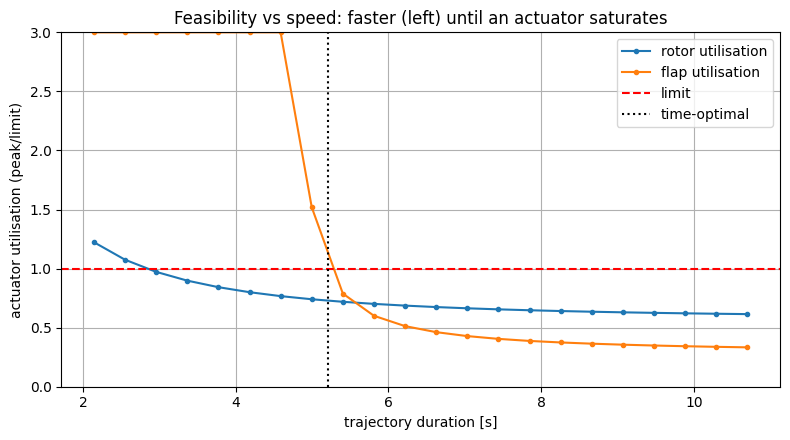

In [4]:
alphas = np.linspace(0.8, 4.0, 22)
w_u, f_u, feasflag = [], [], []
for a in alphas:
    k = allocate_times(m["waypoints"], m["nominal_speed"]) * 0 + knots0 * a
    tpi, tyi = min_snap_trajectory(m["waypoints"], k, yaw=m["yaw"],
                                   v0=m["v0"]/a, v1=m["v1"]/a)
    r = feas.evaluate(tpi, tyi, N=250)
    w_u.append(r['w_util']); f_u.append(r['flap_util']); feasflag.append(r['feasible'])
w_u, f_u = np.array(w_u), np.array(f_u)
durs = alphas * (knots0[-1] - knots0[0])

opt = time_optimal_scale(m["waypoints"], knots0, yaw=m["yaw"], cfg=cfg,
                         v0=m["v0"], v1=m["v1"], N=400)
print(f"time-optimal: alpha*={opt['alpha']:.3f}  duration={opt['feas']['duration']:.2f}s  "
      f"rotor util={opt['feas']['w_util']:.2f}  flap util={opt['feas']['flap_util']:.2f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(durs, np.clip(w_u, 0, 3), '-o', ms=3, label='rotor utilisation')
ax.plot(durs, np.clip(f_u, 0, 3), '-o', ms=3, label='flap utilisation')
ax.axhline(1.0, ls='--', c='r', label='limit')
ax.axvline(opt['feas']['duration'], ls=':', c='k', label='time-optimal')
ax.set_xlabel('trajectory duration [s]'); ax.set_ylabel('actuator utilisation (peak/limit)')
ax.set_title('Feasibility vs speed: faster (left) until an actuator saturates')
ax.set_ylim(0, 3); ax.legend(); ax.grid()
plt.tight_layout(); plt.savefig('plots/p2_feasibility_boundary.png', dpi=110); plt.show()

## 4. The reference trajectory (what the controller would track)

For the time-optimal loop, the flatness transform gives the full reference: attitude,
body rate, collective thrust and the rotor/flap inputs, all as functions of time.

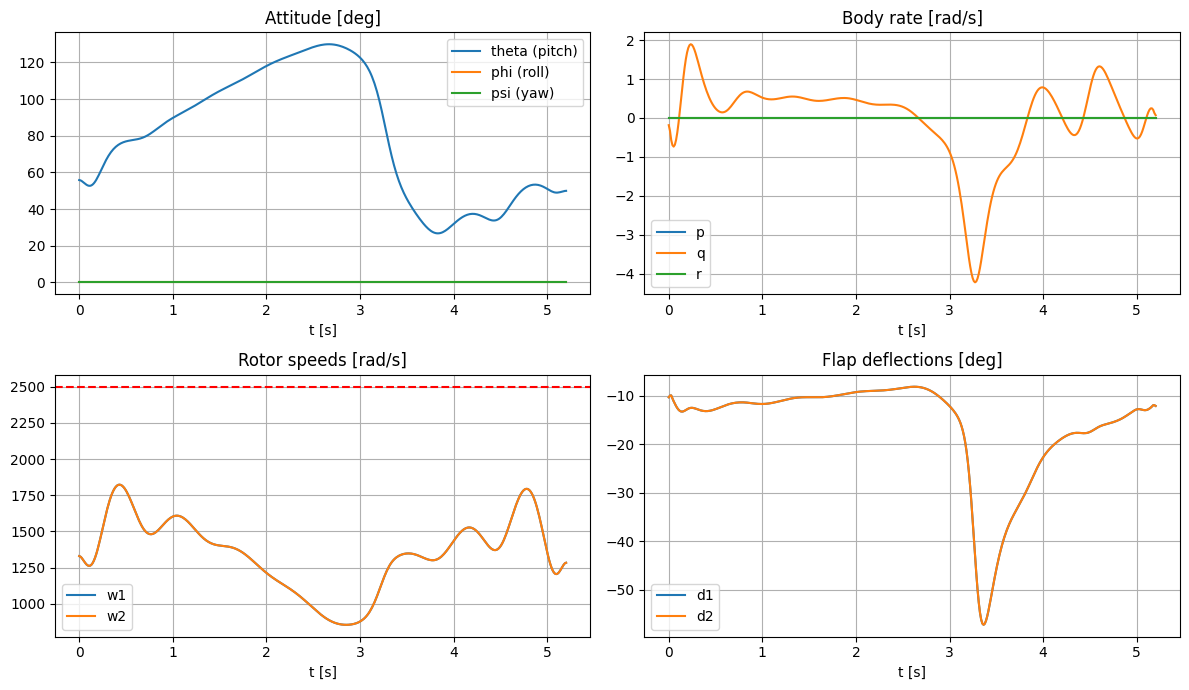

In [5]:
r = opt['feas']; ref = r['ref']; tt = r['ts']
eul = np.array([quat_to_euler_zxy(q) for q in ref['q']])
fig, ax = plt.subplots(2, 2, figsize=(12, 7))
ax[0,0].plot(tt, np.degrees(eul[:,2]), label='theta (pitch)')
ax[0,0].plot(tt, np.degrees(eul[:,1]), label='phi (roll)')
ax[0,0].plot(tt, np.degrees(np.unwrap(eul[:,0])), label='psi (yaw)')
ax[0,0].set_title('Attitude [deg]'); ax[0,0].legend(); ax[0,0].grid()
ax[0,1].plot(tt, ref['Omega']); ax[0,1].legend(['p','q','r'])
ax[0,1].set_title('Body rate [rad/s]'); ax[0,1].grid()
ax[1,0].plot(tt, ref['w1'], label='w1'); ax[1,0].plot(tt, ref['w2'], label='w2')
ax[1,0].axhline(cfg.vehicle.w_max, ls='--', c='r')
ax[1,0].set_title('Rotor speeds [rad/s]'); ax[1,0].legend(); ax[1,0].grid()
ax[1,1].plot(tt, np.degrees(ref['d1']), label='d1'); ax[1,1].plot(tt, np.degrees(ref['d2']), label='d2')
ax[1,1].set_title('Flap deflections [deg]'); ax[1,1].legend(); ax[1,1].grid()
for a in ax.ravel(): a.set_xlabel('t [s]')
plt.tight_layout(); plt.savefig('plots/p2_reference_trajectory.png', dpi=110); plt.show()

## 5. The whole maneuver catalog, time-optimized

Each figure gets scaled to its own actuator limit. The limiting actuator (rotor vs
flap) and the achievable duration differ by maneuver — the tailsitter analogue of
the paper's per-maneuver feasibility results.

> Note: `line` and `knife_edge` collapse to the search floor (tiny duration) because a straight, constant-speed path has no curvature, and with the indoor drag-free coefficients (`cDV=cDT=0`) it needs almost no actuator effort at any speed — so there is no curvature-driven speed limit. The curved figures have genuine feasibility boundaries.

In [6]:
rows = []
for name, gen in maneuvers.CATALOG.items():
    mm = gen()
    k0 = allocate_times(mm["waypoints"], mm["nominal_speed"])
    try:
        o = time_optimal_scale(mm["waypoints"], k0, yaw=mm["yaw"], cfg=cfg,
                               v0=mm["v0"], v1=mm["v1"], N=250)
        f = o['feas']
        lim = 'rotor' if f['w_util'] >= f['flap_util'] else 'flap'
        rows.append((name, f"{f['duration']:.2f}", f"{f['w_util']:.2f}",
                     f"{f['flap_util']:.2f}", lim))
    except Exception as e:
        rows.append((name, 'n/a', '-', '-', str(e)[:20]))
print(f"{'maneuver':26s}{'dur[s]':>8s}{'rotor':>8s}{'flap':>8s}   limited by")
print('-'*62)
for r in rows:
    print(f"{r[0]:26s}{r[1]:>8s}{r[2]:>8s}{r[3]:>8s}   {r[4]}")

maneuver                    dur[s]   rotor    flap   limited by
--------------------------------------------------------------
line                          0.08    0.57    0.29   rotor
loop                          5.20    0.73    1.00   flap
knife_edge                    0.08    0.02    0.00   rotor
climbing_turn                 4.61    0.83    1.00   flap
immelmann                     1.72    1.00    0.57   rotor
split_s                       3.30    0.68    0.72   flap
differential_thrust_turn      2.79    0.74    0.99   flap
racing_gates                  5.41    0.76    1.00   flap


## What Phase 2 delivers / what's next

You can now turn any maneuver (from the catalog or your own waypoints + yaw) into a
smooth, snap-minimising reference trajectory, check its feasibility for *this*
vehicle straight from the flatness transform, and find the fastest feasible timing.
Swap in measured vehicle parameters in the YAML and the feasibility boundaries move
accordingly.

**Phase 3** would add the tailsitter INDI tracking controller (Doc 3) to fly these
references closed-loop in the 6-DOF simulator, closing the two small flatness
approximations (A1/A2 from Phase 1) with feedback.